In [226]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats  # if you have SciPy
import numpy as np


df = pd.read_csv("../data/test.csv")
df1 = pd.read_csv("../data/testone.csv")
# df2 = pd.read_csv("../data/difficult_matches_matched2.csv")

In [227]:
df1.iloc[10]

idx                                                                       28
csv_source                                                         highpairs
domain                                                               Fiction
gid                                                                    56600
htid                                                uc2.ark+=13960=t7dr2vk0r
pubdate                                                                 1870
cidx                                                                       0
sidx                                                                      56
cer                                                                 0.016393
wer                                                                   0.0625
target_gsent               " Did not mamma explain to you , then , how su...
target_hsent               " Did uot mamma explain to you , then , how su...
hsent_norm                 did uot mamma explain to you then how sudden i...

In [228]:
df.nunique()

htid                     344
target_hsent           98439
target_gsent           88780
gid                      188
source_row_index      102495
matched_hsent         101257
source_df                  2
csv_source                 2
domain                     4
pubdate                   92
cidx                      10
sidx                    1182
cer                     5969
wer                      932
lev_similarity          6495
cer_gh                  5942
wer_gh                   930
cer_gh_norm             5837
wer_gh_norm              919
cer_gm                  6981
wer_gm                  1038
cer_gm_norm             6887
wer_gm_norm             1022
cer_hm                  5276
wer_hm                   624
cer_hm_norm             5254
wer_hm_norm              617
cer_diff_from_orig     15281
wer_diff_from_orig       346
dtype: int64

In [ ]:
df1 = df1.rename(columns={
    # "hid": "htid",
    # "gsent": "target_gsent",
    # "hsent": "target_hsent",
    "matched_honed_lev": "matched_hsent",
    # "matched_honed_lev_score": "matched_hsent_lev_score"
    })

In [229]:
df = pd.concat([df, df1], ignore_index=True, sort=False)


In [230]:
df["htid"] = (
    df["htid"]
    .str.replace("+", ":", regex=False)
    .str.replace("=", "/", regex=False)
)

In [382]:
# drop rows with htid hvd.hn6nvw
df = df[df["htid"] != "hvd.hn6nvw"]
df = df[df["match_status"] != "no_match"]


In [404]:
mask = (df["match_status"] == "ok") & (df["matched_hsent"].isna())

count_missing = mask.sum()
count_missing

np.int64(2835)

In [405]:
mask_bad = (
    (df["match_status"] == "ok") &
    (df["matched_hsent"].isna() | (df["matched_hsent"].astype(str).str.strip() == ""))
)

df = df[~mask_bad]

In [406]:
print("Rows:", len(df))
print("Duplicate keys:", df.duplicated(subset=["htid", "gid", "cidx", "sidx"]).sum())
print("Rows with no match from df1:",
      df["target_hsent"].isna().sum())

Rows: 159420
Duplicate keys: 0
Rows with no match from df1: 0


In [407]:
df["cer_new_text"] = df["cer_hm"]
df["wer_new_text"] = df["wer_hm"]

# treat HM_norm as "normalized_text"
df["cer_normalized_text"] = df["cer_hm_norm"]
df["wer_normalized_text"] = df["wer_hm_norm"]

# deltas for new_text vs original
df["cer_delta_new"] = df["cer_diff_from_orig"]
df["wer_delta_new"] = df["wer_diff_from_orig"]

# deltas for normalized vs original (compute from the above)
df["cer_delta_norm"] = df["cer_gm_norm"] - df["cer_hm_norm"]
df["wer_delta_norm"] = df["wer_gm_norm"] - df["wer_hm_norm"]

In [408]:
num_cols = [
    "pubdate",
    "cer", "wer",
    "cer_new_text", "wer_new_text",
    "cer_normalized_text", "wer_normalized_text",
    "cer_delta_new", "cer_delta_norm",
    "wer_delta_new", "wer_delta_norm",
    # optional: keep all the “raw” metrics numeric too
    "cer_gh", "wer_gh",
    "cer_gh_norm", "wer_gh_norm",
    "cer_gm", "wer_gm",
    "cer_gm_norm", "wer_gm_norm",
    "cer_hm", "wer_hm",
    "cer_hm_norm", "wer_hm_norm",
    "cer_diff_from_orig", "wer_diff_from_orig",
]

for col in num_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")


In [409]:
tol = 0.01  # tolerance for float noise

def improvement_stats(delta_series):
    s = delta_series.dropna()
    improved = (s < -tol).sum()
    worse    = (s >  tol).sum()
    same     = ((s >= -tol) & (s <= tol)).sum()
    total    = len(s)
    return {
        "mean": s.mean(),
        "median": s.median(),
        "std": s.std(ddof=1),
        "improved": int(improved),
        "worse": int(worse),
        "same": int(same),
        "pct_improved": 100 * improved / total if total else np.nan,
        "pct_worse":    100 * worse    / total if total else np.nan,
        "pct_same":     100 * same     / total if total else np.nan,
        "total": int(total),
    }

In [410]:
print("\n=== CER new_text vs original (cer_delta_new) ===")
cer_new_stats = improvement_stats(df["cer_delta_new"])
print(cer_new_stats)

print("\n=== WER new_text vs original (wer_delta_new) ===")
wer_new_stats = improvement_stats(df["wer_delta_new"])
print(wer_new_stats)

print("\n=== WER GM_norm vs HM_norm (cer_delta_norm) ===")
cer_norm_stats = improvement_stats(df["cer_delta_norm"])
print(cer_norm_stats)

print("\n=== WER GM_norm vs HM_norm (wer_delta_norm) ===")
wer_norm_stats = improvement_stats(df["wer_delta_norm"])
print(wer_norm_stats)


=== CER new_text vs original (cer_delta_new) ===
{'mean': np.float64(-0.0008695404048237516), 'median': np.float64(0.0), 'std': np.float64(0.0042526486910522705), 'improved': 6877, 'worse': 1303, 'same': 151240, 'pct_improved': np.float64(4.313762388658889), 'pct_worse': np.float64(0.8173378497051813), 'pct_same': np.float64(94.86889976163593), 'total': 159420}

=== WER new_text vs original (wer_delta_new) ===
{'mean': np.float64(-1.7107434747955256e-06), 'median': np.float64(0.0), 'std': np.float64(0.0006830573472820053), 'improved': 1, 'worse': 0, 'same': 159419, 'pct_improved': np.float64(0.0006272738677706687), 'pct_worse': np.float64(0.0), 'pct_same': np.float64(99.99937272613224), 'total': 159420}

=== WER GM_norm vs HM_norm (cer_delta_norm) ===
{'mean': np.float64(0.029059153565731303), 'median': np.float64(0.0196078431372549), 'std': np.float64(0.05936871899032329), 'improved': 29330, 'worse': 102394, 'same': 27696, 'pct_improved': np.float64(18.39794254171371), 'pct_worse': n

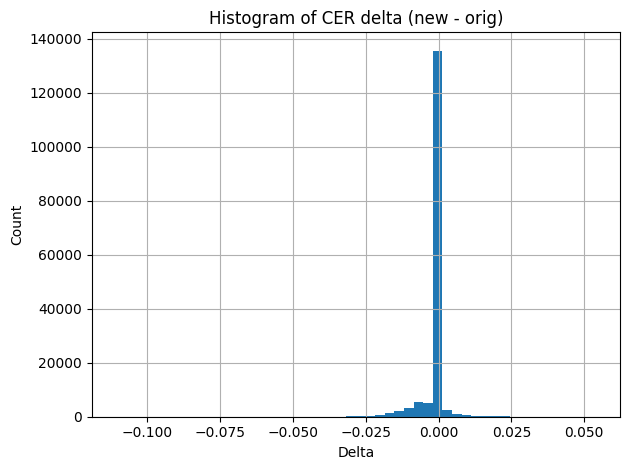

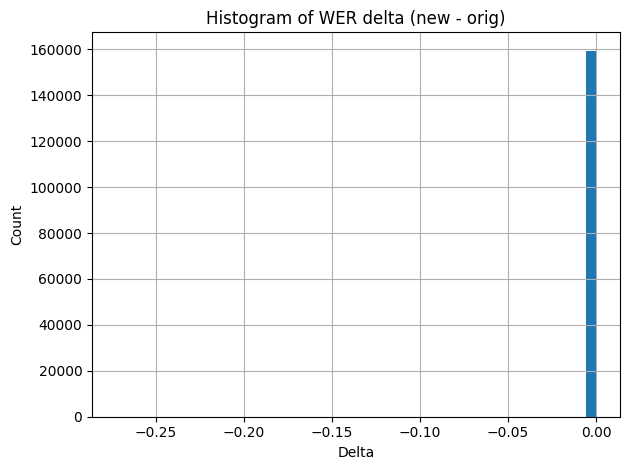

In [411]:
delta_cols = [
    ("CER delta (new - orig)", "cer_delta_new"),
    # ("CER delta (norm - orig)", "cer_delta_norm"),
    ("WER delta (new - orig)", "wer_delta_new"),
    # ("WER delta (norm - orig)", "wer_delta_norm"),
]

for title, col in delta_cols:
    if col in df.columns:
        plt.figure()
        df[col].dropna().hist(bins=50)
        plt.title(f"Histogram of {title}")
        plt.xlabel("Delta")
        plt.ylabel("Count")
        plt.tight_layout()

plt.show()

In [389]:
df["cer_delta_gm"] = df["cer_gm"] - df["cer"]
df["wer_delta_gm"] = df["wer_gm"] - df["wer"]

In [412]:
print("\n=== CER GM vs original ===")
print(improvement_stats(df["cer_delta_gm"]))

print("\n=== WER GM vs original ===")
print(improvement_stats(df["wer_delta_gm"]))


=== CER GM vs original ===
{'mean': np.float64(0.015119927124200598), 'median': np.float64(0.006622516225165499), 'std': np.float64(0.03853836699894864), 'improved': 25653, 'worse': 72471, 'same': 61296, 'pct_improved': np.float64(16.091456529920965), 'pct_worse': np.float64(45.459164471208126), 'pct_same': np.float64(38.449378998870905), 'total': 159420}

=== WER GM vs original ===
{'mean': np.float64(0.08455420383126698), 'median': np.float64(0.029411764705882304), 'std': np.float64(0.1516164133195817), 'improved': 25440, 'worse': 83233, 'same': 50747, 'pct_improved': np.float64(15.957847196085812), 'pct_worse': np.float64(52.20988583615607), 'pct_same': np.float64(31.832266967758123), 'total': 159420}


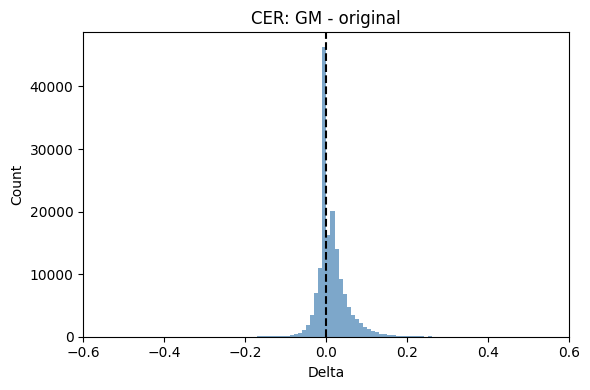

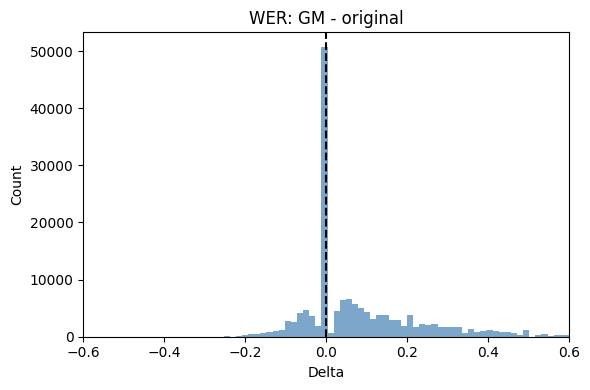

In [413]:
for col, title in [
    ("cer_delta_gm", "CER: GM - original"),
    ("wer_delta_gm", "WER: GM - original")
]:
    s = df[col].dropna()

    plt.figure(figsize=(6, 4))
    plt.hist(s, bins=100, color="steelblue", alpha=0.7)
    plt.axvline(0, linestyle="--", color="black")

    plt.title(title)
    plt.xlabel("Delta")
    plt.ylabel("Count")

    # Zoom in on main region
    plt.xlim(-0.6, 0.6)

    plt.tight_layout()

plt.show()


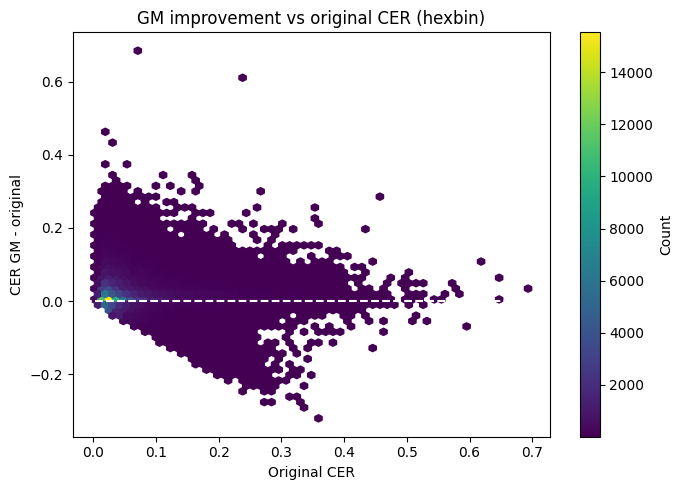

In [414]:
plt.figure(figsize=(7,5))
plt.hexbin(df["cer"], df["cer_delta_gm"], gridsize=60, cmap="viridis", mincnt=1)
plt.axhline(0, linestyle="--", color="white")
plt.colorbar(label="Count")
plt.xlabel("Original CER")
plt.ylabel("CER GM - original")
plt.title("GM improvement vs original CER (hexbin)")
plt.tight_layout()
plt.show()

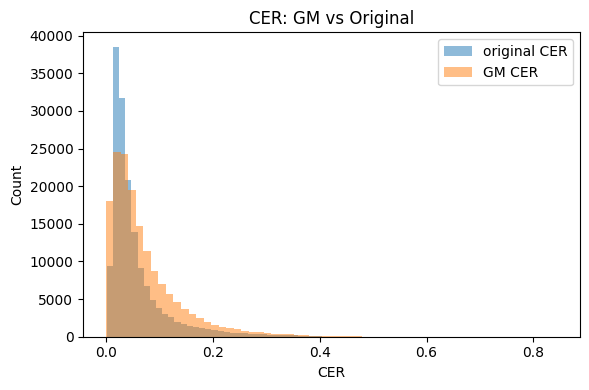

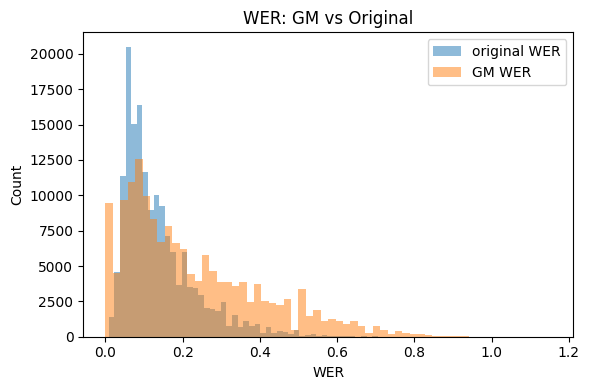

In [415]:
plt.figure(figsize=(6, 4))
plt.hist(df["cer"], bins=60, alpha=0.5, label="original CER")
plt.hist(df["cer_gm"], bins=60, alpha=0.5, label="GM CER")
plt.title("CER: GM vs Original")
plt.xlabel("CER")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.hist(df["wer"], bins=60, alpha=0.5, label="original WER")
plt.hist(df["wer_gm"], bins=60, alpha=0.5, label="GM WER")
plt.title("WER: GM vs Original")
plt.xlabel("WER")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()


In [444]:
worse = df.nlargest(30, "wer_delta_gm")  # most worsened

worse[["target_gsent", "matched_sentence", "wer", "wer_gm"]]
worse.iloc[2]

htid                                        hvd.32044086819455
target_hsent               Proud , too , I 'm afraid , sir . "
target_gsent               Proud , too , I 'm afraid , sir . '
gid                                                        730
source_row_index                                           NaN
matched_hsent                    Proud, too, I'm afraid, sir."
source_df                                                  NaN
csv_source                                            lowpairs
domain                                                 Fiction
pubdate                                                   1858
cidx                                                         4
sidx                                                       113
cer                                                   0.028571
wer                                                   0.090909
lev_similarity                                             NaN
cer_gh                                                0

In [419]:
df_dates = pd.read_csv(
    "../data/htid_marc_latest_updates.csv",
)
date_cols = ["field_005", "field_974d", "DAT0a", "DAT0b",
             "DAT1a", "DAT1b", "DAT2a", "DAT2b"]

In [420]:
for col in date_cols:
    if col in df_dates.columns:
        df_dates[col] = pd.to_datetime(df_dates[col], errors="coerce", utc=True)

cutoff = pd.Timestamp("2022-01-01", tz="UTC")

mask_recent = df_dates[date_cols].ge(cutoff).any(axis=1)
df_recent = df_dates[mask_recent]

recent_htids = set(df_recent["htid"])
df_filtered = df[df["htid"].isin(recent_htids)]

In [421]:
df_filtered.iloc[5500]

htid                                                                                                                                    uiug.30112042036415
target_hsent                         The wmdow , at a little distance from which I know he is having his dinner , stands for him , and I eye that instead .
target_gsent                          The window at a little distance from which I know he is having his dinner , stands for him , and I eye that instead .
gid                                                                                                                                                   43111
source_row_index                                                                                                                                    17866.0
matched_hsent              The window , at a \n little distance from which I know he is \n having his dinner , stands for him , and \n I eye that instead .
source_df                                                       

In [422]:
df_filtered.nunique()

htid                          244
target_hsent               103072
target_gsent                94912
gid                           171
source_row_index            67709
matched_hsent              104947
source_df                       2
csv_source                      2
domain                          4
pubdate                        82
cidx                           10
sidx                         1326
cer                          6819
wer                          1092
lev_similarity               5307
cer_gh                       6767
wer_gh                       1091
cer_gh_norm                  6634
wer_gh_norm                  1073
cer_gm                       7684
wer_gm                       1534
cer_gm_norm                  7521
wer_gm_norm                  1528
cer_hm                       6101
wer_hm                       1484
cer_hm_norm                  6036
wer_hm_norm                  1478
cer_diff_from_orig          17004
wer_diff_from_orig            371
idx           

In [423]:
print("\n=== CER GM vs original ===")
print(improvement_stats(df_filtered["cer_delta_gm"]))

print("\n=== WER GM vs original ===")
print(improvement_stats(df_filtered["wer_delta_gm"]))


=== CER GM vs original ===
{'mean': np.float64(0.012422356911949562), 'median': np.float64(0.004093929349802353), 'std': np.float64(0.0409979684288808), 'improved': 24197, 'worse': 46301, 'same': 36172, 'pct_improved': np.float64(22.683978625667947), 'pct_worse': np.float64(43.40583106777913), 'pct_same': np.float64(33.91019030655292), 'total': 106670}

=== WER GM vs original ===
{'mean': np.float64(0.08211539386147901), 'median': np.float64(0.021276595978723403), 'std': np.float64(0.16281388886590814), 'improved': 23839, 'worse': 54196, 'same': 28635, 'pct_improved': np.float64(22.34836411362145), 'pct_worse': np.float64(50.80716227617887), 'pct_same': np.float64(26.84447361019968), 'total': 106670}


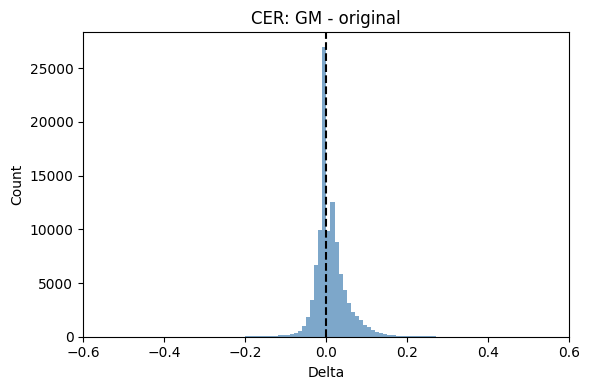

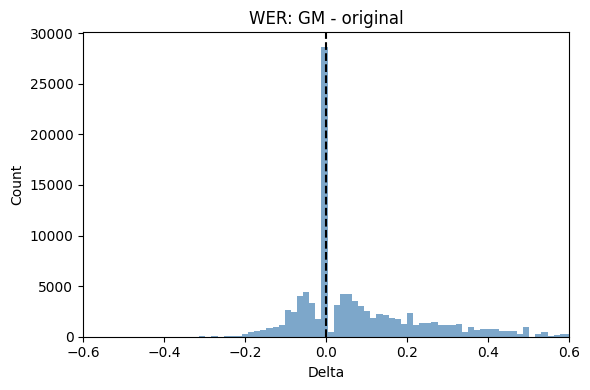

In [424]:
for col, title in [
    ("cer_delta_gm", "CER: GM - original"),
    ("wer_delta_gm", "WER: GM - original")
]:
    s = df_filtered[col].dropna()

    plt.figure(figsize=(6, 4))
    plt.hist(s, bins=100, color="steelblue", alpha=0.7)
    plt.axvline(0, linestyle="--", color="black")

    plt.title(title)
    plt.xlabel("Delta")
    plt.ylabel("Count")

    # Zoom in on main region
    plt.xlim(-0.6, 0.6)

    plt.tight_layout()

plt.show()

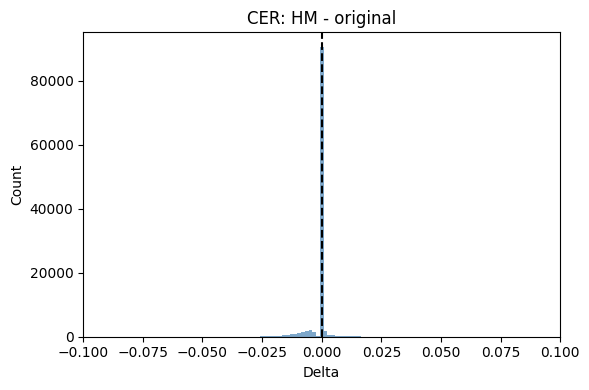

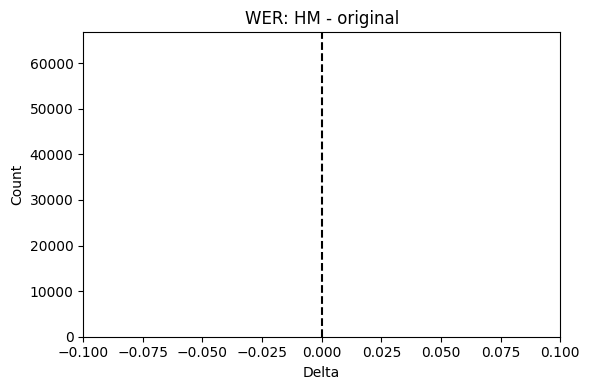

In [439]:
for col, title in [
    ("cer_delta_new", "CER: HM - original"),
    ("wer_delta_new", "WER: HM - original")
]:
    s = df_filtered[col].dropna()

    plt.figure(figsize=(6, 4))
    plt.hist(s, bins=100, color="steelblue", alpha=0.7)
    plt.axvline(0, linestyle="--", color="black")

    plt.title(title)
    plt.xlabel("Delta")
    plt.ylabel("Count")

    # Zoom in on main region
    plt.xlim(-0.1, 0.1)

    plt.tight_layout()

plt.show()

In [426]:
df["wer_delta_gm"] = df["wer_gm"] - df["wer"]
df["cer_delta_gm"] = df["cer_gm"] - df["cer"]

In [427]:
tol = 0.01

def compute_book_improvement_stats(df, delta_col, tol=0.01):
    return (
        df.groupby("htid")
          .agg(
              mean_delta   = (delta_col, "mean"),
              median_delta = (delta_col, "median"),
              improved     = (delta_col, lambda s: (s < -tol).sum()),
              worse        = (delta_col, lambda s: (s >  tol).sum()),
              same         = (delta_col, lambda s: ((s >= -tol) & (s <= tol)).sum()),
              total        = (delta_col, "count"),
          )
          .reset_index()
    )

In [428]:
cer_book_stats = compute_book_improvement_stats(df, "cer_delta_gm")
wer_book_stats = compute_book_improvement_stats(df, "wer_delta_gm")


In [434]:
# mean-based improved
books_cer_mean_improved  = cer_book_stats[cer_book_stats["mean_delta"] < 0]
books_wer_mean_improved  = wer_book_stats[wer_book_stats["mean_delta"] < 0]

# median-based improved
books_cer_median_improved = cer_book_stats[cer_book_stats["median_delta"] < 0]
books_wer_median_improved = wer_book_stats[wer_book_stats["median_delta"] < 0]

# majority of lines improved
books_cer_majority_improved = cer_book_stats[
    cer_book_stats["improved"] < cer_book_stats["worse"]
]

books_wer_majority_improved = wer_book_stats[
    wer_book_stats["improved"] < wer_book_stats["worse"]
]

In [436]:
books_wer_majority_improved.sort_values("mean_delta")

,htid,mean_delta,median_delta,improved,worse,same,total
267,uc2.ark:/13960/t5cc0v60d,0.025240,0.000000e+00,9,34,131,174
248,uc2.ark:/13960/t16m3395z,0.025800,0.000000e+00,19,90,311,420
140,mdp.39015004721281,0.032607,4.117647e-10,31,62,50,143
132,inu.30000105230852,0.033684,0.000000e+00,14,16,16,46
95,hvd.hn1w6l,0.034140,0.000000e+00,174,202,124,500
...,...,...,...,...,...,...,...
151,mdp.39015058682520,0.164645,8.333333e-02,22,435,182,639
327,uva.x000235926,0.165639,1.818182e-01,8,63,15,86
102,hvd.hn5zkz,0.167672,9.090909e-02,24,458,168,650
220,uc1.$b441005,0.168021,7.692308e-02,28,379,228,635


In [ ]:
# (books_cer_majority_improved.sort_values("mean_delta")).to_csv("most_improved_books_cer.csv")

In [ ]:
# (books_wer_majority_improved.sort_values("mean_delta")).to_csv("most_improved_books_wer.csv")


In [315]:
pd.set_option("display.max_colwidth", None)

htid = "hvd.hn6nvw"
df_htid = df[df["htid"] == htid]
df_htid	

,htid,target_hsent,target_gsent,gid,source_row_index,matched_hsent,source_df,csv_source,domain,pubdate,...,cer_normalized_text,wer_normalized_text,cer_delta_new,wer_delta_new,cer_delta_norm,wer_delta_norm,cer_delta_gm,wer_delta_gm,wer_delta_hm,cer_delta_hm
158417,hvd.hn6nvw,"HE evening before my departure for Blithedale , I was returning to my bachelor apartments , SEE ) after attending the wonderful exhibition of the Veiled Lady , when an elderly man , of rather shabby appearance , met me in an obscure part of the street .","The evening before my departure for Blithedale , I was returning to my bachelor apartments , after attending the wonderful exhibition of the Veiled Lady , when an elderly man of rather shabby appearance met me in an obscure part of the street .",2081,NaN,NaN,NaN,lowpairs,Fiction,1881,...,0.988142,1.000000,-4.754098e-10,2.775558e-17,-0.000437,0.0,0.934426,0.886364,0.886364,0.934426
158418,hvd.hn6nvw,""" Mr. Coverdale , "" said he , softly , "" can I speak with you a moment ? """,""" Mr. Coverdale , "" said he softly , "" can I speak with you a moment ? """,2081,NaN,NaN,NaN,lowpairs,Fiction,1881,...,0.959459,1.000000,-2.222222e-10,-5.263158e-11,-0.001126,0.0,0.930556,0.947368,0.947368,0.930556
158419,hvd.hn6nvw,"Since those times , her sisterhood have grown too numerous to attract much individual notice ; nor , in fact , has any one of them ever come before the public under such skilfully contrived circumstances of stage effect as those which at once mystified and illuminated the remarkable perform 12","Since those times her sisterhood have grown too numerous to attract much individual notice ; nor , in fact , has any one of them come before the public under such skilfully contrived circumstances of stage effect as those which at once mystified and illuminated the remarkable performance",2081,NaN,NaN,NaN,lowpairs,Fiction,1881,...,0.989796,1.000000,-3.472223e-03,3.333333e-10,-0.000213,0.0,0.947917,0.916667,0.916667,0.947917
158420,hvd.hn6nvw,"The response , by the by , was of the true Sibylline stamp , nonsensical in its first aspect , yet , on closer study , unfolding a variety of interpretations , one of which has certainly accorded with the event .","The response , by the bye , was of the true Sibylline stamp , nonsensical in its first aspect , yet on closer study unfolding a variety of interpretations , one of which has certainly accorded with the event .",2081,NaN,NaN,NaN,lowpairs,Fiction,1881,...,0.985849,1.000000,-4.784689e-03,0.000000e+00,-0.000203,0.0,0.956938,0.925000,0.925000,0.956938
158421,hvd.hn6nvw,""" I ask your pardon , sir , but I hear you are going to Blithedale to morrow . """,""" I ask your pardon , sir , but I hear you are going to Blithedale tomorrow . """,2081,NaN,NaN,NaN,lowpairs,Fiction,1881,...,0.962500,1.000000,-1.265823e-02,4.163336e-17,-0.000475,0.0,0.936709,0.894737,0.894737,0.936709
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
158635,hvd.hn6nvw,"retribution was , to pine for ever and ever for another sight of that dim , mournful face , which might have been his life long household fireside joy , to desire , and waste life in a feverish quest , and never meet it more .","retribution was , to pine forever and ever for another sight of that dim , mournful face , which might have been his life long household fireside joy , to desire , and waste life in a feverish quest , and never meet it more .",2081,NaN,NaN,NaN,lowpairs,Fiction,1881,...,0.986726,1.000000,-1.333333e-02,-1.304348e-10,-0.000059,0.0,0.968889,0.956522,0.956522,0.968889
158636,hvd.hn6nvw,135 was all one to them ; they took her to their hearts .,It was all one to them ; they took her to their hearts .,2081,NaN,was all one to them; they took he\nAmong them was a,NaN,lowpairs,Fiction,1881,...,0.298246,0.571429,-4.285714e-10,4.285714e-10,-0.012531,0.0,0.232143,0.500000,0.500000,0.232143
158637,hvd.hn6nvw,"So the lady took the silvery veil , which was like woven air , or like some

In [271]:
df_htid.iloc[3]

htid                                                                                                                                 uc1.31175016743323
target_hsent                     But , yielded all that obeisance , they did a good deal for the town , and were generally condescending , and often 10
target_gsent                     But , yielded all that obeisance , they did a good deal for the town , and were generally condescending , and often th
gid                                                                                                                                                4274
source_row_index                                                                                                                                72961.0
matched_hsent              But , yielded all \n that obeisance , they did a good deal for the town , \n and were generally condescending , and often \n
source_df                                                                               

In [ ]:
df["len_gold"] = df["target_gsent"].str.len()
df["len_ocr_old"] = df["matched_hsent"].str.len()
df["len_ocr_new"] = df["new_ocr_text"].str.len()